In [5]:
import numpy as np                  # for numerical operations
import pandas as pd                 # for data handling
import matplotlib.pyplot as plt     # for basic plotting
import seaborn as sns               # for advanced visualization

from scipy.stats import ttest_ind   # for hypothesis testing (t-test)
from sklearn.linear_model import LinearRegression  # for regression model


In [6]:
# Reading the dataset directly from GitHub
data = pd.read_csv(
    "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
)

In [7]:
# Display basic info
print("Shape of dataset:", data.shape)
print("\nFirst 5 rows:\n", data.head())

Shape of dataset: (1338, 7)

First 5 rows:
    age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [8]:
# Checking for missing values
print("\nMissing values in each column:\n", data.isnull().sum())


Missing values in each column:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [9]:
# Getting summary statistics like mean, std, min, max etc.
print("\nStatistical Summary:\n", data.describe())


Statistical Summary:
                age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


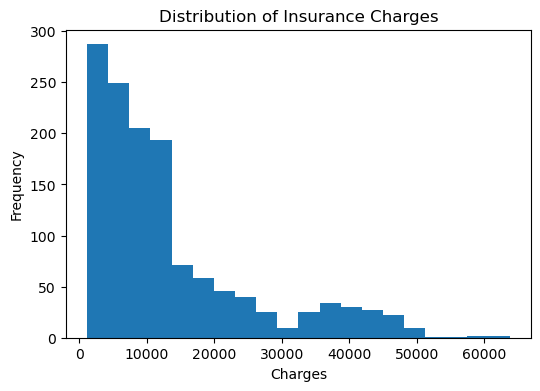

In [10]:
# Plotting histogram of insurance charges
plt.figure(figsize=(6,4))
plt.hist(data['charges'], bins=20)

plt.title("Distribution of Insurance Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")

plt.show()

In [ ]:
# Observation: Helps identify skewness and spread of data

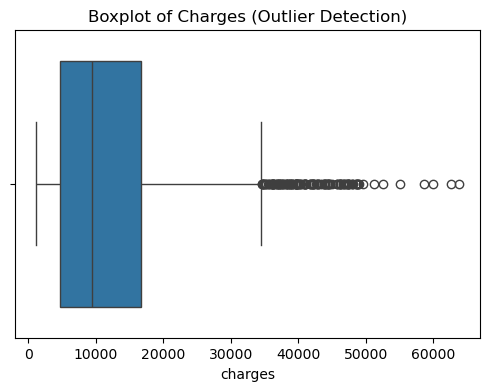

In [11]:
plt.figure(figsize=(6,4))
sns.boxplot(x=data['charges'])

plt.title("Boxplot of Charges (Outlier Detection)")
plt.show()

# Observation: Points outside whiskers indicate outliers

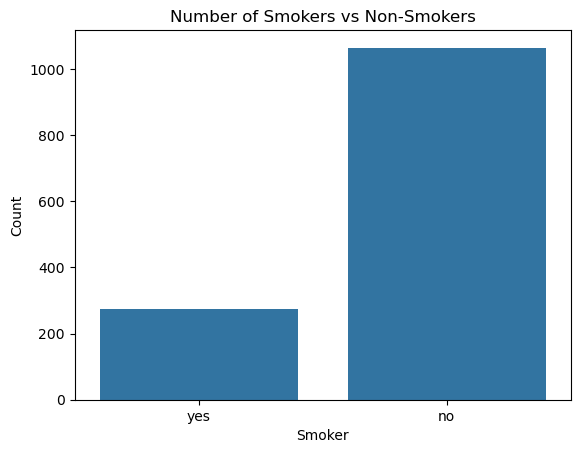

In [42]:
# This plot shows how many people in the dataset are smokers and non-smokers
# It helps us understand the balance of categories in the data

sns.countplot(x=data['smoker'])

plt.title("Number of Smokers vs Non-Smokers")
plt.xlabel("Smoker")
plt.ylabel("Count")

plt.show()

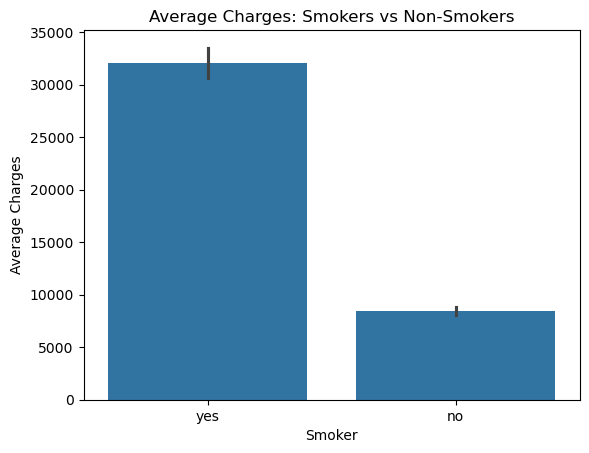

In [43]:
# This plot compares the average insurance charges for smokers and non-smokers
# It helps in understanding whether smoking has an impact on medical costs

sns.barplot(x='smoker', y='charges', data=data)

plt.title("Average Charges: Smokers vs Non-Smokers")
plt.xlabel("Smoker")
plt.ylabel("Average Charges")

plt.show()

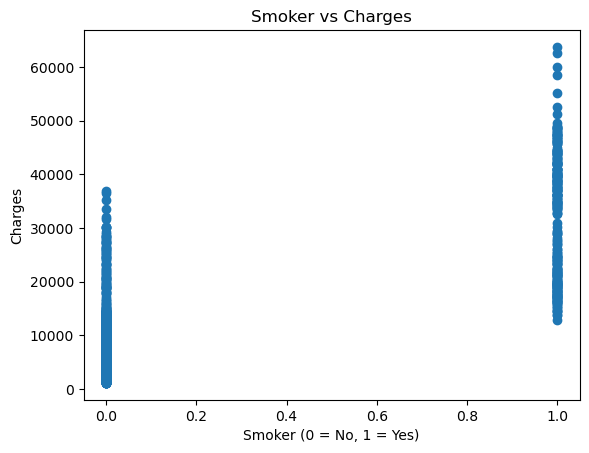

In [44]:
# This scatter plot shows how insurance charges vary based on smoking status
# Here, 0 represents non-smokers and 1 represents smokers
# It helps visualize the difference in charges between the two groups

plt.scatter(data_slr['smoker'], data_slr['charges'])

plt.title("Smoker vs Charges")
plt.xlabel("Smoker (0 = No, 1 = Yes)")
plt.ylabel("Charges")

plt.show()

In [12]:
# Convert categorical data into numeric for correlation
data_encoded = data.copy()

data_encoded['sex'] = data_encoded['sex'].map({'male': 1, 'female': 0})
data_encoded['smoker'] = data_encoded['smoker'].map({'yes': 1, 'no': 0})

# Calculating correlation matrix
correlation = data_encoded.corr(numeric_only=True)

print("\nCorrelation Matrix:\n", correlation)



Correlation Matrix:
                age       sex       bmi  children    smoker   charges
age       1.000000 -0.020856  0.109272  0.042469 -0.025019  0.299008
sex      -0.020856  1.000000  0.046371  0.017163  0.076185  0.057292
bmi       0.109272  0.046371  1.000000  0.012759  0.003750  0.198341
children  0.042469  0.017163  0.012759  1.000000  0.007673  0.067998
smoker   -0.025019  0.076185  0.003750  0.007673  1.000000  0.787251
charges   0.299008  0.057292  0.198341  0.067998  0.787251  1.000000


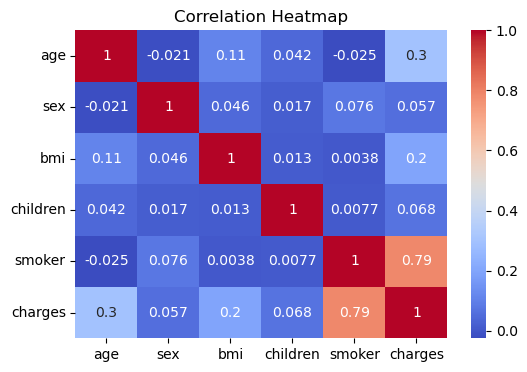

In [13]:
# Visualizing correlation
plt.figure(figsize=(6,4))
sns.heatmap(correlation, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()


In [14]:
# Splitting data into two groups:
# smokers vs non-smokers

smokers = data[data['smoker'] == 'yes']['charges']
non_smokers = data[data['smoker'] == 'no']['charges']

# Performing independent t-test
t_stat, p_value = ttest_ind(smokers, non_smokers)

print("\nT-Test Results:")
print("T-statistic:", t_stat)
print("P-value:", p_value)



T-Test Results:
T-statistic: 46.66492117272371
P-value: 8.271435842179102e-283


In [15]:
# Interpreting result
if p_value < 0.05:
    print("Conclusion: Smoking has a significant impact on insurance charges.")
else:
    print("Conclusion: No significant impact found.")



Conclusion: Smoking has a significant impact on insurance charges.


In [20]:
# Importing required tools for splitting data and evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


In [28]:
# Creating a copy of dataset
data_slr = data.copy()

In [29]:
# Converting 'smoker' into numeric form
# yes = 1 (smoker), no = 0 (non-smoker)
data_slr['smoker'] = data_slr['smoker'].map({'yes': 1, 'no': 0})

In [35]:
# Defining input and output
X = data_slr[['smoker']]   # single input
y = data_slr['charges']    # output


In [36]:
# Splitting the dataset into training and testing sets
# 80% data is used for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [37]:
# Creating the Linear Regression model
model = LinearRegression()

In [38]:
# Training the model using training data
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [39]:
# Predicting charges using test data
y_pred = model.predict(X_test)

In [40]:
# R² Score tells how well the model explains the data (closer to 1 is better)
print("R2 Score:", r2_score(y_test, y_pred))


R2 Score: 0.6602486589056529


In [27]:
# Mean Squared Error shows average squared difference between actual and predicted values
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

Mean Squared Error: 149085057.03839505


In [41]:
# Calculating Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Calculating Root Mean Squared Error
rmse = np.sqrt(mse)

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)

Mean Squared Error (MSE): 52745964.72752624
Root Mean Squared Error (RMSE): 7262.641718240426


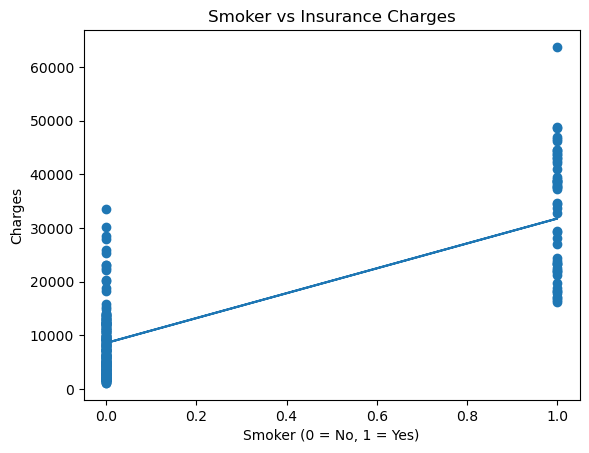

In [46]:
plt.figure()

# Scatter plot (actual values)
plt.scatter(X_test, y_test)

# Regression line
plt.plot(X_test, y_pred)

plt.title("Smoker vs Insurance Charges")
plt.xlabel("Smoker (0 = No, 1 = Yes)")
plt.ylabel("Charges")

plt.show()

In [47]:
# Predictions on training data
y_train_pred = model.predict(X_train)

# Predictions on testing data
y_test_pred = model.predict(X_test)

# R2 scores
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Training R2 Score:", train_r2)
print("Testing R2 Score:", test_r2)


Training R2 Score: 0.6084975246707405
Testing R2 Score: 0.6602486589056529
